In [12]:
print("hello!")

hello!


In [15]:
import requests
import pandas as pd
import numpy as np

In [ ]:
url = "https://pokeapi.co/api/v2/pokemon?limit=150"

response = requests.get(url)

print(response.status_code)

200


In [ ]:
data = response.json()

print(data.keys())

dict_keys(['count', 'next', 'previous', 'results'])


In [ ]:
pokemon_list = data["results"]

print(len(pokemon_list))

150


In [ ]:
pokemon_list = response.json()

print(type(pokemon_list))

<class 'dict'>


In [ ]:
pokemon_list["results"][:5]

[{'name': 'bulbasaur', 'url': 'https://pokeapi.co/api/v2/pokemon/1/'},
 {'name': 'ivysaur', 'url': 'https://pokeapi.co/api/v2/pokemon/2/'},
 {'name': 'venusaur', 'url': 'https://pokeapi.co/api/v2/pokemon/3/'},
 {'name': 'charmander', 'url': 'https://pokeapi.co/api/v2/pokemon/4/'},
 {'name': 'charmeleon', 'url': 'https://pokeapi.co/api/v2/pokemon/5/'}]

In [ ]:
pokemon_records = []

for pokemon in pokemon_list["results"]:
    pokemon_response = requests.get(pokemon["url"])
    pokemon_data = pokemon_response.json()
    
    stats = {
        stat["stat"]["name"]: stat["base_stat"]
        for stat in pokemon_data["stats"]
    }
    
    types = [
        pokemon_type["type"]["name"]
        for pokemon_type in pokemon_data["types"]
    ]
    
    pokemon_records.append({
        "id": pokemon_data["id"],
        "name": pokemon_data["name"],
        "height": pokemon_data["height"],
        "weight": pokemon_data["weight"],
        "base_experience": pokemon_data["base_experience"],
        "hp": stats.get("hp"),
        "attack": stats.get("attack"),
        "defense": stats.get("defense"),
        "special_attack": stats.get("special-attack"),
        "special_defense": stats.get("special-defense"),
        "speed": stats.get("speed"),
        "primary_type": types[0],
        "secondary_type": types[1] if len(types) > 1 else None,
        "ability_count": len(pokemon_data["abilities"])
    })

I know want to create pandas dataframe

In [ ]:
pokemon_df = pd.DataFrame(pokemon_records)

pokemon_df.head()

,id,name,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,primary_type,secondary_type,ability_count
0,1,bulbasaur,7,69,64,45,49,49,65,65,45,grass,poison,2
1,2,ivysaur,10,130,142,60,62,63,80,80,60,grass,poison,2
2,3,venusaur,20,1000,236,80,82,83,100,100,80,grass,poison,2
3,4,charmander,6,85,62,39,52,43,60,50,65,fire,None,2
4,5,charmeleon,11,190,142,58,64,58,80,65,80,fire,None,2


In [ ]:
pokemon_df.shape

(150, 14)

I know have 150 rows and 14 columns

##Part 1 Checkpoint question

### What was the API endpoint you used?

I used the PokéAPI Pokémon endpoint:

https://pokeapi.co/api/v2/pokemon?limit=150

### How many records did you fetch?

I collected 150 Pokémon records.

### How many columns?

The dataset contains 14 columns.

### Did the API have any rate limits or auth requirements?

PokéAPI does not require authentication for its REST API. The documentation
states that rate limiting has been removed, although users are asked to
follow the fair-use policy and avoid unnecessary requests.

### What were the column data types initially?

The dataset contains integer columns for values such as height, weight,
and battle statistics, while name and Pokémon type columns are strings.
The secondary_type column may contain missing values because some Pokémon
only have one type.


In [ ]:
pokemon_df.to_csv("pokemon_raw.csv", index=False)

In [ ]:
pokemon_clean = pd.read_csv("pokemon_raw.csv")

In [ ]:
pokemon_clean.head()

,id,name,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,primary_type,secondary_type,ability_count
0,1,bulbasaur,7,69,64,45,49,49,65,65,45,grass,poison,2
1,2,ivysaur,10,130,142,60,62,63,80,80,60,grass,poison,2
2,3,venusaur,20,1000,236,80,82,83,100,100,80,grass,poison,2
3,4,charmander,6,85,62,39,52,43,60,50,65,fire,NaN,2
4,5,charmeleon,11,190,142,58,64,58,80,65,80,fire,NaN,2


In [ ]:
pokemon_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               150 non-null    int64 
 1   name             150 non-null    object
 2   height           150 non-null    int64 
 3   weight           150 non-null    int64 
 4   base_experience  150 non-null    int64 
 5   hp               150 non-null    int64 
 6   attack           150 non-null    int64 
 7   defense          150 non-null    int64 
 8   special_attack   150 non-null    int64 
 9   special_defense  150 non-null    int64 
 10  speed            150 non-null    int64 
 11  primary_type     150 non-null    object
 12  secondary_type   67 non-null     object
 13  ability_count    150 non-null    int64 
dtypes: int64(11), object(3)
memory usage: 16.5+ KB


In [ ]:
pokemon_clean.describe()

,id,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,ability_count
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,12.000000,462.313333,134.153333,63.973333,72.733333,68.013333,66.920000,65.860000,68.860000,2.626667
std,43.445368,9.636341,595.473881,67.035174,28.534671,26.752574,26.880293,28.502095,24.129413,26.995657,0.550127
min,1.000000,2.000000,1.000000,39.000000,10.000000,5.000000,5.000000,15.000000,20.000000,15.000000,1.000000
25%,38.250000,7.000000,99.250000,65.000000,45.000000,50.500000,50.000000,45.000000,48.500000,45.750000,2.000000
50%,75.500000,10.000000,300.000000,142.000000,60.000000,70.000000,65.000000,63.000000,65.000000,69.000000,3.000000
75%,112.750000,15.000000,563.750000,175.000000,79.750000,91.500000,82.250000,85.000000,80.000000,90.000000,3.000000
max,150.000000,88.000000,4600.000000,395.000000,250.000000,134.000000,180.000000,154.000000,125.000000,150.000000,3.000000


In [ ]:
missing_count = pokemon_clean.isnull().sum()

missing_count

id                  0
name                0
height              0
weight              0
base_experience     0
hp                  0
attack              0
defense             0
special_attack      0
special_defense     0
speed               0
primary_type        0
secondary_type     83
ability_count       0
dtype: int64

In [ ]:
missing_percentage = (
    pokemon_clean.isnull().mean() * 100
).round(2)

missing_percentage

id                  0.00
name                0.00
height              0.00
weight              0.00
base_experience     0.00
hp                  0.00
attack              0.00
defense             0.00
special_attack      0.00
special_defense     0.00
speed               0.00
primary_type        0.00
secondary_type     55.33
ability_count       0.00
dtype: float64

In [ ]:
pokemon_clean["secondary_type"] = (
    pokemon_clean["secondary_type"].fillna("None")
)

In [34]:
pokemon_clean.dtypes

id                  int64
name               object
height              int64
weight              int64
base_experience     int64
hp                  int64
attack              int64
defense             int64
special_attack      int64
special_defense     int64
speed               int64
primary_type       object
secondary_type     object
ability_count       int64
dtype: object

In [35]:
pokemon_clean["id"] = pokemon_clean["id"].astype(int)

In [37]:
numeric_columns = [
    "height",
    "weight",
    "base_experience",
    "hp",
    "attack",
    "defense",
    "special_attack",
    "special_defense",
    "speed",
    "ability_count"
]

pokemon_clean[numeric_columns] = pokemon_clean[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

In [38]:
pokemon_clean.duplicated().sum()

np.int64(0)

I checked the dataset for duplicate rows using pandas `.duplicated()`.
No duplicate rows were found, so no rows needed to be removed.

In [39]:
pokemon_clean["weight"].describe()

count     150.000000
mean      462.313333
std       595.473881
min         1.000000
25%        99.250000
50%       300.000000
75%       563.750000
max      4600.000000
Name: weight, dtype: float64

In [40]:
pokemon_clean["height"].describe()

count    150.000000
mean      12.000000
std        9.636341
min        2.000000
25%        7.000000
50%       10.000000
75%       15.000000
max       88.000000
Name: height, dtype: float64

In [43]:
min
max

<function max>

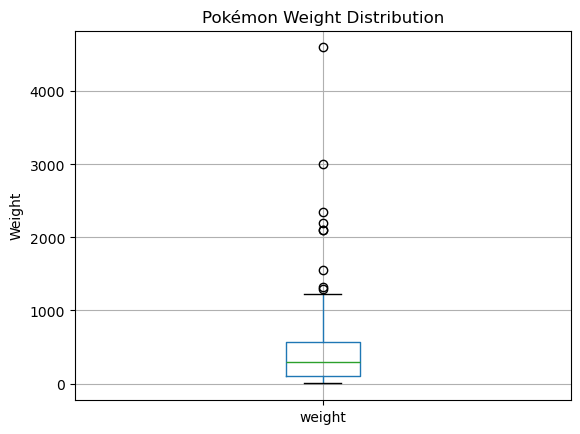

In [44]:
import matplotlib.pyplot as plt

pokemon_clean.boxplot(column="weight")

plt.title("Pokémon Weight Distribution")
plt.ylabel("Weight")
plt.show()


I inspected weight and height for unusually large or small values.
Some Pokémon have much larger weights than others, but these values may
represent legitimate Pokémon characteristics rather than data errors.

In [45]:
pokemon_clean.to_csv("pokemon_clean.csv", index=False)

In [46]:
pokemon_clean["attack"].describe()

count    150.000000
mean      72.733333
std       26.752574
min        5.000000
25%       50.500000
50%       70.000000
75%       91.500000
max      134.000000
Name: attack, dtype: float64

In [47]:
pokemon_clean[[
    "hp",
    "attack",
    "defense",
    "speed"
]].describe()

,hp,attack,defense,speed
count,150.000000,150.000000,150.000000,150.000000
mean,63.973333,72.733333,68.013333,68.860000
std,28.534671,26.752574,26.880293,26.995657
min,10.000000,5.000000,5.000000,15.000000
25%,45.000000,50.500000,50.000000,45.750000
50%,60.000000,70.000000,65.000000,69.000000
75%,79.750000,91.500000,82.250000,90.000000
max,250.000000,134.000000,180.000000,150.000000


In [48]:
print("Attack mean:", pokemon_clean["attack"].mean())
print("Attack median:", pokemon_clean["attack"].median())

print("Defense mean:", pokemon_clean["defense"].mean())
print("Defense median:", pokemon_clean["defense"].median())

print("Speed mean:", pokemon_clean["speed"].mean())
print("Speed median:", pokemon_clean["speed"].median())

Attack mean: 72.73333333333333
Attack median: 70.0
Defense mean: 68.01333333333334
Defense median: 65.0
Speed mean: 68.86
Speed median: 69.0


In [49]:
pokemon_clean["primary_type"].value_counts()

primary_type
water       28
normal      22
poison      14
grass       12
fire        12
bug         12
electric     9
rock         9
ground       8
fighting     7
psychic      7
ghost        3
dragon       3
fairy        2
ice          2
Name: count, dtype: int64

In [50]:
pokemon_clean["primary_type"].mode()[0]

'water'

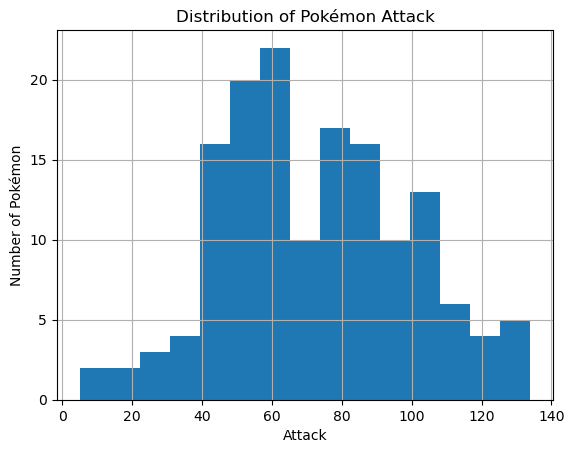

In [51]:
pokemon_clean["attack"].hist(bins=15)

plt.title("Distribution of Pokémon Attack")
plt.xlabel("Attack")
plt.ylabel("Number of Pokémon")
plt.show()

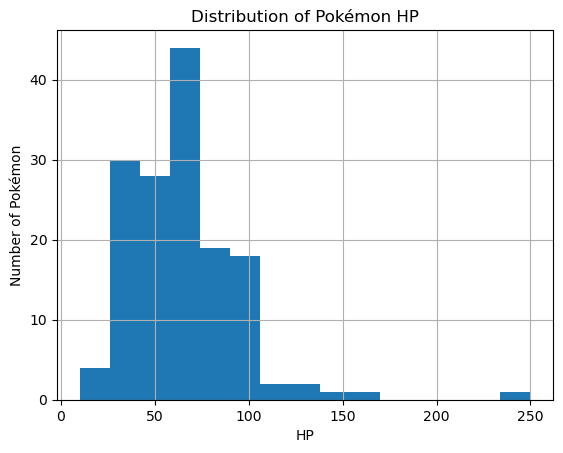

In [52]:
pokemon_clean["hp"].hist(bins=15)

plt.title("Distribution of Pokémon HP")
plt.xlabel("HP")
plt.ylabel("Number of Pokémon")
plt.show()

The HP values are spread across a wide range. Most Pokémon appear to
cluster around the middle of the distribution, while a smaller number
have high values

In [53]:
correlation_matrix = pokemon_clean[
    [
        "hp",
        "attack",
        "defense",
        "special_attack",
        "special_defense",
        "speed"
    ]
].corr()

correlation_matrix


,hp,attack,defense,special_attack,special_defense,speed
hp,1.000000,0.290848,0.110968,0.229199,0.487731,-0.051357
attack,0.290848,1.000000,0.478537,0.133495,0.364237,0.194989
defense,0.110968,0.478537,1.000000,0.180089,0.131953,-0.062011
special_attack,0.229199,0.133495,0.180089,1.000000,0.523204,0.402496
special_defense,0.487731,0.364237,0.131953,0.523204,1.000000,0.381251
speed,-0.051357,0.194989,-0.062011,0.402496,0.381251,1.000000


In [54]:
numeric_stats = [
    "hp",
    "attack",
    "defense",
    "special_attack",
    "special_defense",
    "speed"
]

correlation_matrix = pokemon_clean[numeric_stats].corr()

correlation_matrix

,hp,attack,defense,special_attack,special_defense,speed
hp,1.000000,0.290848,0.110968,0.229199,0.487731,-0.051357
attack,0.290848,1.000000,0.478537,0.133495,0.364237,0.194989
defense,0.110968,0.478537,1.000000,0.180089,0.131953,-0.062011
special_attack,0.229199,0.133495,0.180089,1.000000,0.523204,0.402496
special_defense,0.487731,0.364237,0.131953,0.523204,1.000000,0.381251
speed,-0.051357,0.194989,-0.062011,0.402496,0.381251,1.000000


In [55]:
average_attack_by_type = (
    pokemon_clean
    .groupby("primary_type")["attack"]
    .mean()
    .sort_values(ascending=False)
)

average_attack_by_type

primary_type
fighting    102.857143
dragon       94.000000
ground       84.375000
fire         83.916667
rock         82.222222
poison       75.142857
grass        70.666667
water        70.250000
normal       68.863636
ice          67.500000
bug          63.750000
electric     62.000000
fairy        57.500000
psychic      54.428571
ghost        50.000000
Name: attack, dtype: float64

In [56]:
average_defense_by_type = (
    pokemon_clean
    .groupby("primary_type")["defense"]
    .mean()
    .sort_values(ascending=False)
)

average_defense_by_type

primary_type
rock        110.000000
ground       86.250000
water        77.500000
grass        69.583333
dragon       68.333333
ice          67.500000
poison       67.000000
electric     64.666667
fire         62.583333
fighting     61.000000
fairy        60.500000
bug          57.083333
normal       53.545455
psychic      51.428571
ghost        45.000000
Name: defense, dtype: float64

In [57]:
average_speed_by_type = (
    pokemon_clean
    .groupby("primary_type")["speed"]
    .mean()
    .sort_values(ascending=False)
)

average_speed_by_type


primary_type
electric    100.000000
ghost        95.000000
psychic      92.000000
ice          90.000000
fire         84.000000
normal       69.772727
water        67.714286
dragon       66.666667
fighting     66.142857
poison       58.785714
rock         58.333333
ground       58.125000
bug          57.083333
grass        52.083333
fairy        47.500000
Name: speed, dtype: float64

## Part 2 Checkpoint Answers

### 1. How many missing values did you find? In which columns?
I found 83 missing values, all in the secondary_type column.

### 2. Did you drop rows, fill values, or keep them? Why?
I kept the missing valuesbecause a missing secondary_type means the Pokémon does not have a secondary type.

### 3. Were there duplicates? How did you handle them?
No duplicate rows were foundso no rows were removed.

### 4. Did any data type conversions surprise you?
No 

## Part 3 Checkpoint Questions

### Which column has the most missing data?

secondary_type with 83 missin gvalues

### What is the correlation between your strongest pair of variables?

0.523204

### What's the most common value in your categorical column?

Grass

### What's one unexpected pattern you found?

Some Pokémon have very high weight despite relatively modest height, likelenusaur with weight 1000, height 20

# Conclusion

This analysis showed that Pokémon differ considerably in their battle
statistics, physical characteristics, and types. The dataset was cleaned
by handling missing secondary types, checking data types, checking for
duplicate and investigating potential outliers.

The next step would be to create visualizations that compare Pokémon types
with battle statistics. A boxplot showing attack distributions by type
would be particularly useful. A correlation heatmap could also help show
relationships between the different battle statistics.